In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.io as sio
from scipy.spatial.distance import cdist
import json

import CMR_IA as cmr

cmr.analysis.setup_notebook()

SAVEFIG = True
SAVEDATA = False

# Exp 1

In [2]:
# Load the Matlab events structure into a tidy DataFrame
def load_exp1_events(matpath, fields):
    events = sio.loadmat(matpath)["events"][:, 0]

    def scalar(rec, field):
        v = np.array(rec[field]).squeeze()
        if v.size == 0:
            return np.nan
        if v.dtype.kind in "US":
            return str(v)
        if v.size == 1:
            return v.item()
        return v

    return pd.DataFrame([{f: scalar(r, f) for f in fields} for r in events])


fields = ["subject", "typeevent", "halfnum", "blocknum", "trialnum", "face", "facename", "recallname", "recallface", "iscorrect", "intrusion", "vocalization", "rt", "distance"]
df = load_exp1_events("data/original_experiments/Experiment1/Experiment1.mat", fields)
print(f"{len(df)} events, {df.subject.nunique()} subjects")
df.typeevent.value_counts().sort_index()

12463 events, 25 subjects


typeevent
1    4000
2    4000
3    3963
4     500
Name: count, dtype: int64

typeevent: 1 = study, 2 = test, 3 = recall, 4 = sound record.

## Neighborhood Effect

In [3]:
# A "neighbor" is within this Euclidean distance in MDS space
NEIGH_RADIUS = 3

# Extract the fixed 4-D MDS coordinates of the 16 faces from the event structure
events = sio.loadmat("data/original_experiments/Experiment1/Experiment1.mat")["events"][:, 0]
coords = {}
for r in events:
    f = np.array(r["face"]).squeeze()
    c = np.array(r["facecoordinates"]).squeeze()
    if f.size == 1 and c.size == 4:
        coords[int(f)] = c
face_coords = np.array([coords[i] for i in range(16)])
face_coords.shape

(16, 4)

In [4]:
# Number of neighbors of each cue face within its own study set (subject, half)
study = df[df.typeevent == 1][["subject", "halfnum", "face"]].drop_duplicates()
neighbors = {}
for (subj, half), grp in study.groupby(["subject", "halfnum"]):
    faces = sorted(grp.face.astype(int).unique())
    dmat = cdist(face_coords[faces], face_coords[faces])
    counts = ((dmat < NEIGH_RADIUS) & (dmat > 0)).sum(axis=1)
    for face, n in zip(faces, counts):
        neighbors[(subj, half, face)] = n

# Combine the two halves into 10 logical blocks (block b and b+10 are the same cycle)
test = df[df.typeevent == 2].copy()
test["neighbors"] = [neighbors[(r.subject, r.halfnum, int(r.face))] for r in test.itertuples()]
test["block"] = test.blocknum.where(test.blocknum <= 10, test.blocknum - 10)
print("neighbor range:", test.neighbors.min(), "-", test.neighbors.max())

neighbor range: 1 - 7


In [5]:
# Collapse 6 and 7 neighbors into a single "6-7" bin
test["nbin"] = test.neighbors.clip(upper=6)
nbin_labels = {1: "1", 2: "2", 3: "3", 4: "4", 5: "5", 6: "6-7"}
acc_n = test.groupby(["subject", "nbin"]).iscorrect.mean().reset_index()
neigh_acc = acc_n.groupby("nbin").iscorrect.agg(["mean", "sem"])
neigh_acc

,mean,sem
nbin,,
1,0.806250,0.052131
2,0.765217,0.038665
3,0.675076,0.032538
4,0.640110,0.036826
5,0.606141,0.042334
6,0.567857,0.061367


In [6]:
# Three-level density grouping (low 1-2, medium 3-4, high 5-7)
# The paper averages each subject's per-condition mean, so a subject must contribute all three cells
# Subjects missing a cell are dropped ("Two participants were excluded due to missing data")
test_correct = test[test.iscorrect == 1].copy()
test_correct["nbin"] = test_correct.neighbors.clip(upper=6)
rt_n = test_correct.groupby(["subject", "nbin"]).rt.mean().reset_index()
neigh_rt = rt_n.groupby("nbin").rt.agg(["mean", "sem"])

test["density"] = pd.cut(test.neighbors, [0, 2, 4, 7], labels=["low", "medium", "high"])
test_correct["density"] = pd.cut(test_correct.neighbors, [0, 2, 4, 7], labels=["low", "medium", "high"])
acc_ps = test.groupby(["subject", "density"], observed=True).iscorrect.mean().unstack().dropna()
rt_ps = test_correct.groupby(["subject", "density"], observed=True).rt.mean().unstack().dropna()
print("P(correct) by density:", acc_ps.mean().round(3).to_dict())
print("RT(correct) by density:", rt_ps.mean().round(0).to_dict())

P(correct) by density: {'low': 0.767, 'medium': 0.664, 'high': 0.595}
RT(correct) by density: {'low': 1836.0, 'medium': 2158.0, 'high': 2365.0}


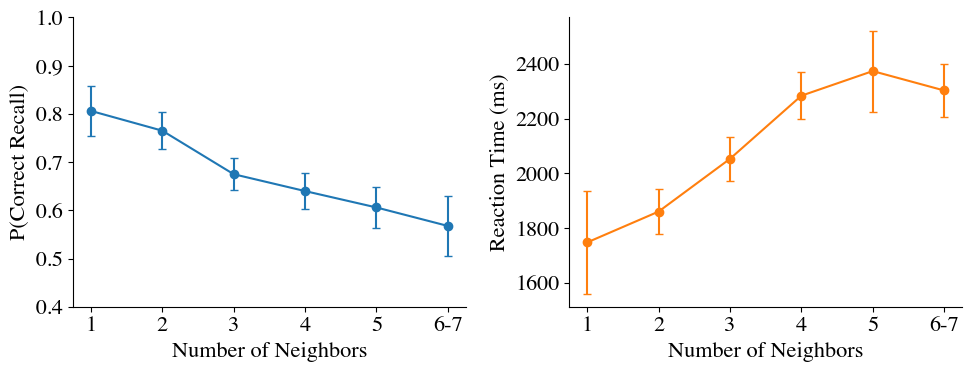

In [7]:
# Plot the neighborhood effect as in paper
x = list(neigh_acc.index)
labels = [nbin_labels[i] for i in x]
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].errorbar(x, neigh_acc["mean"], yerr=neigh_acc["sem"], marker="o", capsize=3)
axes[0].set(xlabel="Number of Neighbors", ylabel="P(Correct Recall)", ylim=(0.4, 1))
axes[0].set_xticks(x)
axes[0].set_xticklabels(labels)
axes[1].errorbar(x, neigh_rt["mean"], yerr=neigh_rt["sem"], marker="o", capsize=3, color="C1")
axes[1].set(xlabel="Number of Neighbors", ylabel="Reaction Time (ms)")
axes[1].set_xticks(x)
axes[1].set_xticklabels(labels)
for ax in axes:
    ax.spines[["right", "top"]].set_visible(False)
fig.tight_layout()
plt.show()

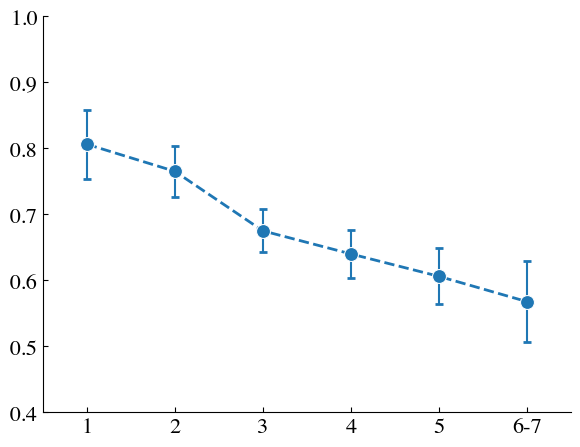

In [8]:
# Plot for CMR-IA paper
x = list(neigh_acc.index)
labels = [nbin_labels[i] for i in x]

fig, ax = plt.subplots(figsize=(6, 4.5))
fig.subplots_adjust(left=0.1, right=0.98, bottom=0.1, top=0.98)

ax.errorbar(x=x, y=neigh_acc["mean"], yerr=neigh_acc["sem"], marker=None, capsize=3, capthick=2, linestyle="none")
sns.lineplot(x=x, y=neigh_acc["mean"], ax=ax, marker="o", color="C0", markersize=10, linewidth=2, linestyle="--")

ax.spines[["right", "top"]].set_visible(False)
ax.tick_params(axis="y", direction="in")
ax.tick_params(axis="x", direction="in")
plt.ylim([0.4, 1])
plt.xlim([0.5, 6.5])
plt.xticks(ticks=x, labels=["1", "2", "3", "4", "5", "6-7"])
plt.xlabel("Number of Neighbours")
plt.ylabel("P(Correct)")

if SAVEFIG:
    ax.set(xlabel=None, ylabel=None)
    plt.savefig("figures/simu8_PantelisExp1_correct-neighbor.pdf")
plt.show()

## ILI

Conditional P(ILI) = (number of ILIs at a given cue-to-error distance) / (number of *possible* ILIs at that distance).

In [9]:
# Recall df is different from test, in that there could be multiple responses for one test item
recall = df[(df.typeevent == 3) & (df.vocalization != 1)].copy()
recall["block"] = recall.blocknum.where(recall.blocknum <= 10, recall.blocknum - 10)

# Distance bins
dist_edges = [0.5, 1, 1.5, 2, 2.5, 3, 3.5, np.inf]
dist_labels = ["1", "1.5", "2", "2.5", "3", "3.5", ">3.5"]


def bin_dist(values):
    return pd.cut(values, dist_edges, labels=dist_labels)


# Denominator: possible ILIs (distance from each cue to the other study-set faces)
poss_rows = []
for (subj, half, blk), grp in test.groupby(["subject", "halfnum", "blocknum"]):
    faces = grp.face.astype(int).values
    for f in faces:
        d = cdist(face_coords[[f]], face_coords[faces])[0]
        d = d[d > 0]
        poss_rows.append(pd.DataFrame({"subject": subj, "dbin": bin_dist(d)}))
possible = pd.concat(poss_rows, ignore_index=True)
poss_counts = possible.groupby(["subject", "dbin"], observed=True).size().rename("possible")

# Numerator: actual ILIs (non-correct, non-extralist, non-vocal recalls)
ili = recall[(recall.intrusion == 0) & (recall.iscorrect == 0) & (recall.distance > 0)].copy()
ili["dbin"] = bin_dist(ili.distance)
ili_counts = ili.groupby(["subject", "dbin"], observed=True).size().rename("ili")

# Per-subject conditional probability, then mean +/- SEM across subjects
cond = pd.concat([poss_counts, ili_counts], axis=1).fillna(0)
cond["p"] = cond.ili / cond.possible.replace(0, np.nan)
ili_prob = cond.reset_index().groupby("dbin", observed=True).p.agg(["mean", "sem"]).reindex(dist_labels)
ili_rt = ili.groupby(["subject", "dbin"], observed=True).rt.mean().reset_index().groupby("dbin", observed=True).rt.agg(["mean", "sem"]).reindex(dist_labels)
ili_prob

,mean,sem
dbin,,
1,0.151316,0.023684
1.5,0.162674,0.016937
2,0.052267,0.007581
2.5,0.048692,0.005998
3,0.038944,0.006513
3.5,0.020730,0.003134
>3.5,0.013982,0.002564


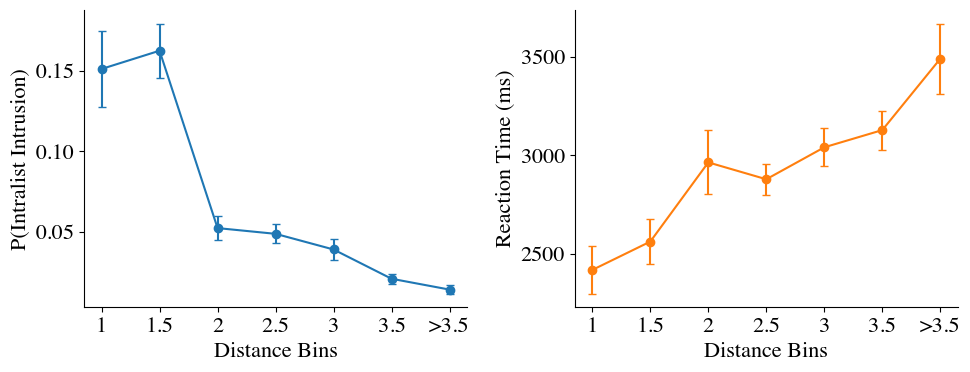

In [10]:
# Plot the ILI effect as in the paper
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
xpos = np.arange(len(dist_labels))
axes[0].errorbar(xpos, ili_prob["mean"], yerr=ili_prob["sem"], marker="o", capsize=3)
axes[0].set(xlabel="Distance Bins", ylabel="P(Intralist Intrusion)")
axes[0].set_xticks(xpos)
axes[0].set_xticklabels(dist_labels)
axes[1].errorbar(xpos, ili_rt["mean"], yerr=ili_rt["sem"], marker="o", capsize=3, color="C1")
axes[1].set(xlabel="Distance Bins", ylabel="Reaction Time (ms)")
axes[1].set_xticks(xpos)
axes[1].set_xticklabels(dist_labels)
for ax in axes:
    ax.spines[["right", "top"]].set_visible(False)
fig.tight_layout()
plt.show()

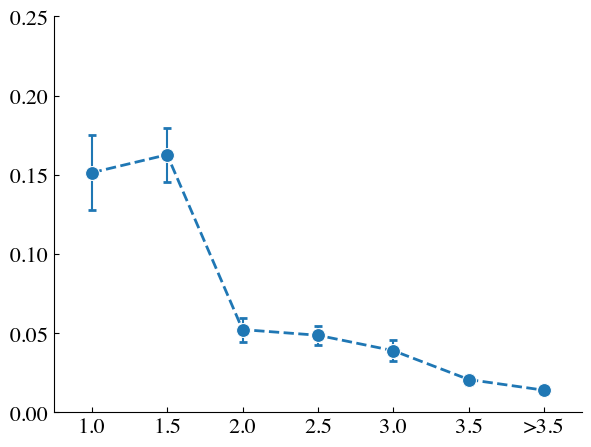

In [11]:
# Plot ILI for CMR-IA paper
fig, ax = plt.subplots(figsize=(6, 4.5))
fig.subplots_adjust(left=0.1, right=0.98, bottom=0.1, top=0.98)

xpos = np.arange(len(dist_labels))
ax.errorbar(x=xpos, y=ili_prob["mean"], yerr=ili_prob["sem"], marker=None, capsize=3, capthick=2, linestyle="none")
sns.lineplot(x=xpos, y=ili_prob["mean"], ax=ax, marker="o", color="C0", markersize=10, linewidth=2, linestyle="--")

ax.spines[["right", "top"]].set_visible(False)
ax.tick_params(axis="y", direction="in")
ax.tick_params(axis="x", direction="in")
plt.ylim([0, 0.25])
plt.xlim([-0.5, 6.5])
plt.xticks(ticks=xpos, labels=["1.0", "1.5", "2.0", "2.5", "3.0", "3.5", ">3.5"])
plt.xlabel("Distance Bins")
plt.ylabel("ILI Conditional Response Probability")

if SAVEFIG:
    ax.set(xlabel=None, ylabel=None)
    plt.savefig("figures/simu8_PantelisExp1_ILI-distance.pdf")
plt.show()

## Extra: Learning Curve (Table 1)

In [12]:
# P(correct) and correct-recall RT per block, averaged over subjects
recall = df[(df.typeevent == 3) & (df.vocalization != 1)].copy()
recall["block"] = recall.blocknum.where(recall.blocknum <= 10, recall.blocknum - 10)
acc_subj = test.groupby(["subject", "block"]).iscorrect.mean().reset_index()
lc_acc = acc_subj.groupby("block").iscorrect.agg(["mean", "sem"])
rt_subj = recall[recall.iscorrect == 1].groupby(["subject", "block"]).rt.mean().reset_index()
lc_rt = rt_subj.groupby("block").rt.agg(["mean", "sem"])
lc = pd.DataFrame({"P_correct": lc_acc["mean"].round(2), "RT": lc_rt["mean"].round(0)})
lc

,P_correct,RT
block,,
1,0.28,2481.0
2,0.44,2482.0
3,0.56,2240.0
4,0.66,2187.0
5,0.66,2166.0
6,0.70,2124.0
7,0.76,2067.0
8,0.81,2086.0
9,0.80,1976.0


# Exp 3

In [13]:
# Load the Matlab events structure into a tidy DataFrame
def load_exp3_events(matpath, fields):
    events = sio.loadmat(matpath)["events"][:, 0]

    def scalar(rec, field):
        v = np.array(rec[field]).squeeze()
        if v.size == 0:
            return np.nan
        if v.dtype.kind in "US":
            return str(v)
        if v.size == 1:
            return v.item()
        return v

    return pd.DataFrame([{f: scalar(r, f) for f in fields} for r in events])


fields = ["subject", "typeevent", "blocknum", "trialnum", "face", "name", "studyface", "istarget", "confidence", "iscorrect", "rt", "facename", "recallname", "exintrusion", "inintrusion", "distance"]
df = load_exp3_events("data/original_experiments/Experiment3/Experiment3.mat", fields)
df["confidence"] = pd.to_numeric(df.confidence, errors="coerce")
print(f"{len(df)} events, {df.subject.nunique()} subjects")
df.typeevent.value_counts().sort_index()

18314 events, 36 subjects


typeevent
0      35
1    5760
2    5760
3    5760
4     560
5     439
Name: count, dtype: int64

typeevent: 1 = study, 2 = test, 3 = response to test, 4 = cue in final recall, 5 = response in final recall. 

In [14]:
# Fixed 4-D MDS coordinates of the 16 faces, and neighbor count per face
events = sio.loadmat("data/original_experiments/Experiment3/Experiment3.mat")["events"][:, 0]
coords = {}
for r in events:
    f = np.array(r["face"]).squeeze()
    c = np.array(r["facecoordinates"]).squeeze()
    if f.size == 1 and c.size == 4:
        coords[int(f)] = c
face_coords = np.array([coords[i] for i in range(16)])
dmat = cdist(face_coords, face_coords)
neighbor_count = ((dmat < NEIGH_RADIUS) & (dmat > 0)).sum(axis=1)
print("neighbors per face:", neighbor_count, "range", neighbor_count.min(), "-", neighbor_count.max())

neighbors per face: [10  8  9  6  8  7 10  5  5 10  7  8  8  8 10  9] range 5 - 10


In [15]:
# Recognition responses with neighborhood and a binary "yes" decision
YES_THRESHOLD = 4
resp = df[df.typeevent == 3].copy()
resp["neighbors"] = resp.face.astype(int).map(lambda x: neighbor_count[x])
resp["yes"] = (resp.confidence >= YES_THRESHOLD).astype(int)
resp["density"] = pd.cut(resp.neighbors, [4, 6, 8, 10], labels=["low", "medium", "high"])

In [16]:
# Compute Ag: the area under the empirical confidence ROC
def compute_ag(sub):
    pos = sub[sub.istarget == 1].confidence.values
    neg = sub[sub.istarget == 0].confidence.values
    if len(pos) == 0 or len(neg) == 0:
        return np.nan
    criteria = [7, 6, 5, 4, 3, 2, 1, 0]
    tpr = [(pos >= c).mean() for c in criteria]
    fpr = [(neg >= c).mean() for c in criteria]
    return np.trapz(tpr, fpr)

## Neighborhood effect

In [17]:
# Get Ag, HR, FAR, confidence, RT by density
ag_dens = resp.groupby(["subject", "density"], observed=True).apply(compute_ag, include_groups=False).rename("Ag").reset_index().groupby("density", observed=True).Ag.agg(["mean", "sem"])
hr_dens = resp[resp.istarget == 1].groupby(["subject", "density"], observed=True).yes.mean().reset_index().groupby("density", observed=True).yes.agg(["mean", "sem"])
far_dens = resp[resp.istarget == 0].groupby(["subject", "density"], observed=True).yes.mean().reset_index().groupby("density", observed=True).yes.agg(["mean", "sem"])
conf_dens = resp[resp.istarget == 1].groupby(["subject", "density"], observed=True).confidence.mean().reset_index().groupby("density", observed=True).confidence.agg(["mean", "sem"])
hits = resp[(resp.istarget == 1) & (resp.yes == 1)]
rt_dens = hits.groupby(["subject", "density"], observed=True).rt.mean().reset_index().groupby("density", observed=True).rt.agg(["mean", "sem"])

print("Ag by density:", ag_dens["mean"].round(3).to_dict())
print("HR by density:", hr_dens["mean"].round(3).to_dict())
print("FAR by density:", far_dens["mean"].round(3).to_dict())
print("Target confidence by density:", conf_dens["mean"].round(2).to_dict())
print("Hit RT by density:", rt_dens["mean"].round(0).to_dict())

Ag by density: {'low': 0.814, 'medium': 0.811, 'high': 0.784}
HR by density: {'low': 0.83, 'medium': 0.809, 'high': 0.786}
FAR by density: {'low': 0.28, 'medium': 0.281, 'high': 0.303}
Target confidence by density: {'low': 4.66, 'medium': 4.54, 'high': 4.38}
Hit RT by density: {'low': 2160.0, 'medium': 2170.0, 'high': 2364.0}


In [18]:
# # Plot Ag by density for CMR-IA paper
# ag_dens_plot = ag_dens.reset_index()

# fig, ax = plt.subplots(figsize=(6, 4.5))
# fig.subplots_adjust(left=0.1, right=0.98, bottom=0.1, top=0.98)

# ax.errorbar(x=ag_dens_plot["density"], y=ag_dens_plot["mean"], yerr=ag_dens_plot["sem"], marker=None, capsize=3, capthick=2, linestyle="none")
# sns.lineplot(data=ag_dens_plot, x="density", y="mean", ax=ax, marker="o", color="C0", markersize=10, linewidth=2, linestyle="--")

# ax.spines[["right", "top"]].set_visible(False)
# ax.tick_params(axis="y", direction="in")
# ax.tick_params(axis="x", direction="in")
# plt.ylim([0.7, 0.9])
# plt.xlim([-0.5, 2.5])
# plt.xlabel("Number of Neighbors Group")
# plt.ylabel("Ag")

# if SAVEFIG:
#     ax.set(xlabel=None, ylabel=None)
#     plt.savefig("figures/simu8_PantelisExp3_Ag.pdf")
# plt.show()

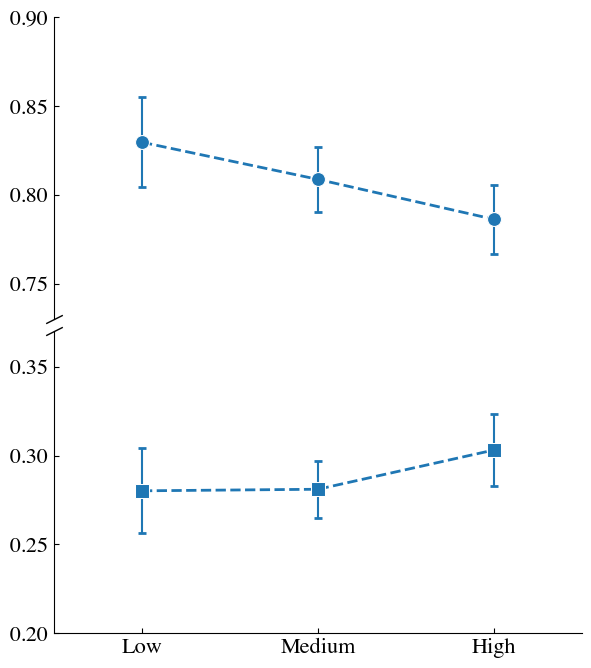

In [19]:
# Plot HR and FAR by density (stacked, broken y-axis) for CMR-IA paper
hr_plot = hr_dens.reset_index()
far_plot = far_dens.reset_index()
xpos = np.arange(3)

fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True, figsize=(6, 7))
fig.subplots_adjust(left=0.1, right=0.98, bottom=0.1, top=0.98, hspace=0.04)

ax1.errorbar(x=xpos, y=hr_plot["mean"], yerr=hr_plot["sem"], marker=None, capsize=3, capthick=2, linestyle="none")
ax2.errorbar(x=xpos, y=far_plot["mean"], yerr=far_plot["sem"], marker=None, capsize=3, capthick=2, linestyle="none")
sns.lineplot(x=xpos, y=hr_plot["mean"].to_numpy(), ax=ax1, marker="o", color="C0", markersize=10, linewidth=2, linestyle="--")
sns.lineplot(x=xpos, y=far_plot["mean"].to_numpy(), ax=ax2, marker="s", color="C0", markersize=10, linewidth=2, linestyle="--")

ax1.set_ylim(0.73, 0.90)
ax2.set_ylim(0.20, 0.37)
for ax in (ax1, ax2):
    ax.tick_params(axis="y", direction="in")
    ax.tick_params(axis="x", direction="in")
    ax.spines.right.set_visible(False)
ax1.spines.bottom.set_visible(False)
ax1.spines.top.set_visible(False)
ax2.spines.top.set_visible(False)
ax1.tick_params(axis="x", which="both", bottom=False)

# Slanted break marks between the two panels
d = 0.5
kwargs = dict(marker=[(-1, -d), (1, d)], markersize=12, linestyle="none", color="k", mec="k", mew=1, clip_on=False)
ax1.plot(0, 0, transform=ax1.transAxes, **kwargs)
ax2.plot(0, 1, transform=ax2.transAxes, **kwargs)

ax2.set_xticks(xpos)
ax2.set_xticklabels(["Low", "Medium", "High"])
ax1.set_yticks(np.arange(0.75, 0.91, 0.05))
ax2.set_yticks(np.arange(0.20, 0.36, 0.05))
ax2.set_xlim(-0.5, 2.5)
ax1.set_ylabel("HR")
ax2.set_ylabel("FAR")
ax2.set_xlabel("Number of Neighbours Group")

if SAVEFIG:
    ax1.set_ylabel(None)
    ax2.set_ylabel(None)
    ax2.set_xlabel(None)
    plt.savefig("figures/simu8_PantelisExp3_hrfar-neighbor.pdf")
plt.show()

## Probe Distance Effect

In [20]:
# Following Exp 1, the bin label is the upper edge of a fixed-width (1.0) bin
lure_edges = [0.5, 1.5, 2.5, 3.5, 4.5]
lure_labels = ["1.5", "2.5", "3.5", "4.5"]
resp["dbin"] = np.where(resp.istarget == 1, "Targets", pd.cut(resp.distance, lure_edges, labels=lure_labels).astype(object))
dbin_order = ["Targets"] + lure_labels

# Yes rate
yes_subj = resp.groupby(["subject", "dbin"], observed=True).yes.mean().reset_index()
yes_dist = yes_subj.groupby("dbin", observed=True).yes.agg(["mean", "sem"]).reindex(dbin_order)
print("Yes rate by probe distance:", yes_dist["mean"].round(3).to_dict())

# Confidence
conf_subj = resp.groupby(["subject", "dbin"], observed=True).confidence.mean().reset_index()
conf_dist = conf_subj.groupby("dbin", observed=True).confidence.agg(["mean", "sem"]).reindex(dbin_order)
print("Confidence by probe distance:", conf_dist["mean"].round(3).to_dict())

# RT split into the four response types
resp["resp_type"] = np.select([(resp.istarget == 1) & (resp.yes == 1), (resp.istarget == 1) & (resp.yes == 0), (resp.istarget == 0) & (resp.yes == 0), (resp.istarget == 0) & (resp.yes == 1)], ["hit", "miss", "cr", "fa"], default="na")
print("Mean RT by response type:", resp.groupby("resp_type").rt.mean().round(0).to_dict())

Yes rate by probe distance: {'Targets': 0.804, '1.5': 0.523, '2.5': 0.349, '3.5': 0.265, '4.5': 0.203}
Confidence by probe distance: {'Targets': 4.504, '1.5': 3.601, '2.5': 2.813, '3.5': 2.529, '4.5': 2.248}
Mean RT by response type: {'cr': 2391.0, 'fa': 2589.0, 'hit': 2221.0, 'miss': 2883.0}


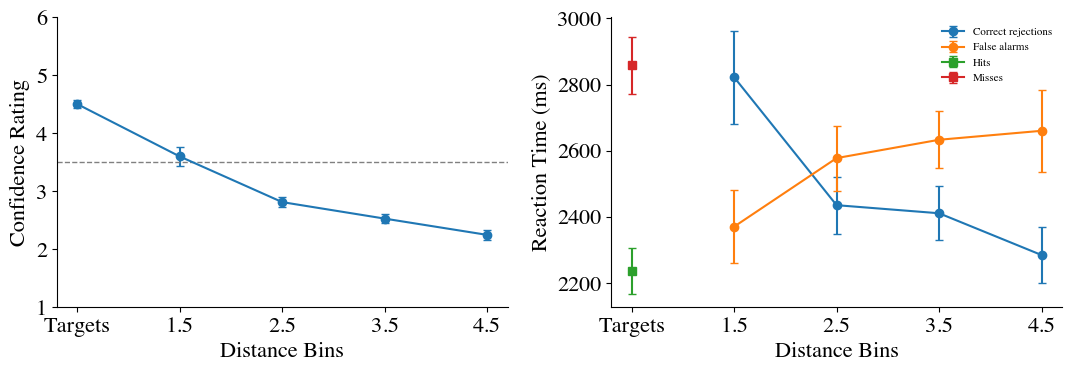

In [21]:
# Plot confidence and RT against probe distance
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
xpos = np.arange(len(dbin_order))
axes[0].errorbar(xpos, conf_dist["mean"], yerr=conf_dist["sem"], marker="o", capsize=3)
axes[0].axhline(YES_THRESHOLD - 0.5, ls="--", color="gray", lw=1)
axes[0].set(xlabel="Distance Bins", ylabel="Confidence Rating", ylim=(1, 6))
axes[0].set_xticks(xpos)
axes[0].set_xticklabels(dbin_order)

for rtype, label in [("cr", "Correct rejections"), ("fa", "False alarms")]:
    sub = resp[(resp.resp_type == rtype) & (resp.istarget == 0)]
    sub = sub.assign(dbin=pd.cut(sub.distance, lure_edges, labels=lure_labels))
    tbl = sub.groupby(["subject", "dbin"], observed=True).rt.mean().reset_index().groupby("dbin", observed=True).rt.agg(["mean", "sem"]).reindex(lure_labels)
    axes[1].errorbar(np.arange(1, len(lure_labels) + 1), tbl["mean"], yerr=tbl["sem"], marker="o", capsize=3, label=label)
for rtype, label in [("hit", "Hits"), ("miss", "Misses")]:
    val = resp[resp.resp_type == rtype].groupby("subject").rt.mean()
    axes[1].errorbar([0], [val.mean()], yerr=[val.sem()], marker="s", capsize=3, label=label)
axes[1].set(xlabel="Distance Bins", ylabel="Reaction Time (ms)")
axes[1].set_xticks(xpos)
axes[1].set_xticklabels(dbin_order)
axes[1].legend(frameon=False, fontsize=8)
for ax in axes:
    ax.spines[["right", "top"]].set_visible(False)
fig.tight_layout()
plt.show()

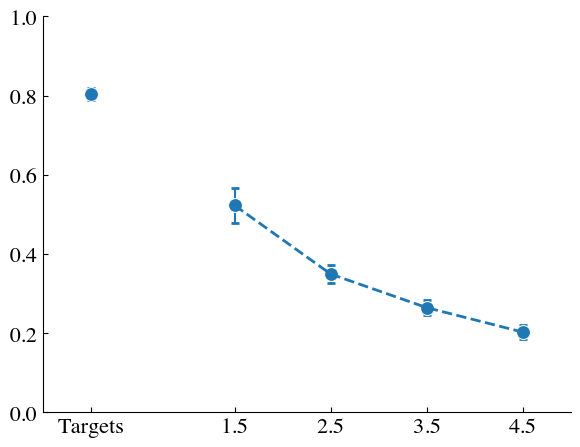

In [22]:
# Plot yes rate by probe distance for CMR-IA paper
yes_dist_plot = yes_dist.reset_index()
xpos = [0, 1.5, 2.5, 3.5, 4.5]

fig, ax = plt.subplots(figsize=(6, 4.5))
fig.subplots_adjust(left=0.1, right=0.98, bottom=0.1, top=0.98)

ax.errorbar(x=xpos, y=yes_dist_plot["mean"], yerr=yes_dist_plot["sem"], marker=None, capsize=3, capthick=2, linestyle="none")
sns.lineplot(data=yes_dist_plot, x=xpos, y="mean", ax=ax, marker="o", color="C0", markersize=10, linewidth=0)
sns.lineplot(data=yes_dist_plot.query("dbin != 'Targets'"), x=xpos[1:], y="mean", ax=ax, marker=None, color="C0", markersize=10, linewidth=2, linestyle="--")

ax.spines[["right", "top"]].set_visible(False)
ax.tick_params(axis="y", direction="in")
ax.tick_params(axis="x", direction="in")
plt.xlim([-0.5, 5])
plt.ylim([0, 1])
plt.xticks(ticks=xpos, labels=yes_dist_plot["dbin"])
plt.xlabel("Distance Bins")
plt.ylabel("Yes Rate")

if SAVEFIG:
    ax.set(xlabel=None, ylabel=None)
    plt.savefig("figures/simu8_PantelisExp3_yes-distance.pdf")
plt.show()

## Final cued recall

The cue events (typeevent == 4) carry one row per cued face with its response outcome. As with the Exp 1 ILI analysis, this is a CONDITIONAL probability: responses at each cue-to-name distance are divided by the number of *possible* responses at that distance. A correct recall sits at distance 0 (exactly one possibility per cue, so that bin equals the unconditional correct-recall rate); intralist intrusions sit at distance > 0 (possibilities = the other study-set faces at that distance). Two subjects with no usable final-recall data (all-NaN correct rate) are dropped from both the correct-recall and the ILI analyses.

In [23]:
# Distance bins (label = upper edge of a width-1.0 bin), with a distance-0 bin for correct recalls
fin_edges = [-0.5, 0.5, 1.5, 2.5, 3.5, 4.5]
fin_labels = ["0", "1.5", "2.5", "3.5", "4.5"]


def bin_fin(values):
    return pd.cut(values, fin_edges, labels=fin_labels)


# One row per cued face; drop subjects whose correct-recall rate is NaN (no usable data)
final = df[df.typeevent == 4].copy()
final["face"] = final.face.astype(int)
valid = final.groupby("subject").iscorrect.mean().dropna().index
print("dropped subjects:", final.subject[~final.subject.isin(valid)].unique().tolist())
final = final[final.subject.isin(valid)]
print("correct recall rate:", round(final.groupby("subject").iscorrect.mean().mean(), 4))

# Denominator: for each cued face, distances to all 16 faces (self = 0 = the correct option)
poss_rows = []
for subj, grp in final.groupby("subject"):
    for f in grp.face.values:
        d = cdist(face_coords[[f]], face_coords)[0]
        poss_rows.append(pd.DataFrame({"subject": subj, "dbin": bin_fin(d)}))
possible = pd.concat(poss_rows, ignore_index=True)
poss_counts = possible.groupby(["subject", "dbin"], observed=True).size().rename("possible")

# Numerator: responses with an in-space distance (correct = 0, ILI > 0; extralist/omission dropped)
resp_fin = final[(final.exintrusion == 0) & final.distance.notna()].copy()
resp_fin["dbin"] = bin_fin(resp_fin.distance)
resp_counts = resp_fin.groupby(["subject", "dbin"], observed=True).size().rename("recalled")

# Per-subject conditional probability, then mean +/- SEM across subjects
cond = pd.concat([poss_counts, resp_counts], axis=1)
cond["recalled"] = cond.recalled.fillna(0)
cond["p"] = cond.recalled / cond.possible
fin_prob = cond.reset_index().groupby("dbin", observed=True).p.agg(["mean", "sem"]).reindex(fin_labels)
fin_rt = resp_fin.groupby(["subject", "dbin"], observed=True).rt.mean().reset_index().groupby("dbin", observed=True).rt.agg(["mean", "sem"]).reindex(fin_labels)
fin_prob

dropped subjects: ['ARF19', 'ARF21']
correct recall rate: 0.3807


,mean,sem
dbin,,
0,0.380682,0.031646
1.5,0.115530,0.014165
2.5,0.045455,0.005218
3.5,0.018759,0.002286
4.5,0.008658,0.002897


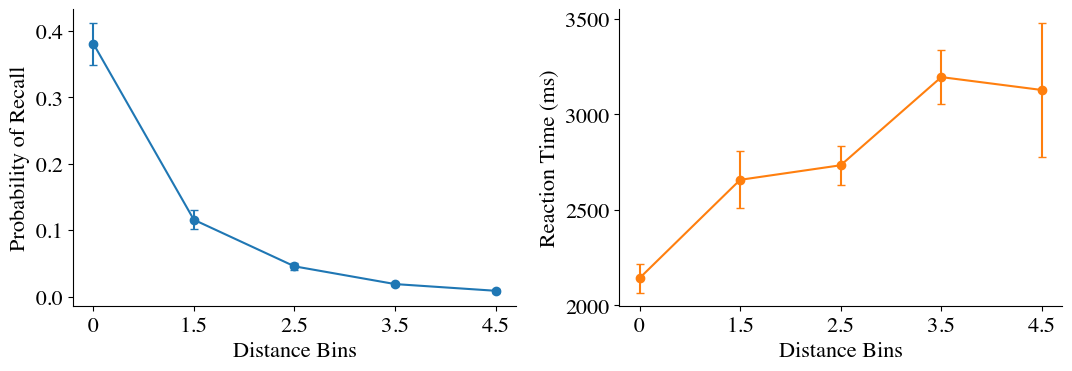

In [24]:
# Plot final cued recall
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
xpos = np.arange(len(fin_labels))
axes[0].errorbar(xpos, fin_prob["mean"], yerr=fin_prob["sem"], marker="o", capsize=3)
axes[0].set(xlabel="Distance Bins", ylabel="Probability of Recall")
axes[0].set_xticks(xpos)
axes[0].set_xticklabels(fin_labels)
axes[1].errorbar(xpos, fin_rt["mean"], yerr=fin_rt["sem"], marker="o", capsize=3, color="C1")
axes[1].set(xlabel="Distance Bins", ylabel="Reaction Time (ms)")
axes[1].set_xticks(xpos)
axes[1].set_xticklabels(fin_labels)
for ax in axes:
    ax.spines[["right", "top"]].set_visible(False)
fig.tight_layout()
plt.show()

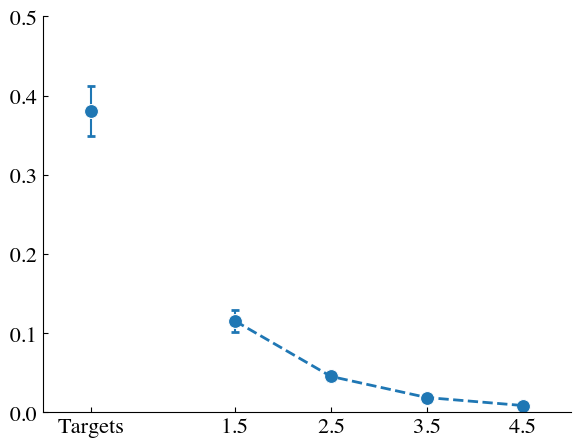

In [25]:
# Plot correct rate and ILI for CMR-IA paper
fin_prob_plot = fin_prob.reset_index()
xpos = [0, 1.5, 2.5, 3.5, 4.5]

fig, ax = plt.subplots(figsize=(6, 4.5))
fig.subplots_adjust(left=0.1, right=0.98, bottom=0.1, top=0.98)

ax.errorbar(x=xpos, y=fin_prob_plot["mean"], yerr=fin_prob_plot["sem"], marker=None, capsize=3, capthick=2, linestyle="none")
sns.lineplot(data=fin_prob_plot, x=xpos, y="mean", ax=ax, marker="o", color="C0", markersize=10, linewidth=0)
sns.lineplot(data=fin_prob_plot.query("dbin != '0'"), x=xpos[1:], y="mean", ax=ax, marker=None, color="C0", markersize=10, linewidth=2, linestyle="--")

ax.spines[["right", "top"]].set_visible(False)
ax.tick_params(axis="y", direction="in")
ax.tick_params(axis="x", direction="in")
plt.xlim([-0.5, 5])
plt.ylim([0, 0.5])
plt.xticks(ticks=xpos, labels=["Targets", "1.5", "2.5", "3.5", "4.5"])
plt.xlabel("Distance Bins")
plt.ylabel("Probability of Recall")

if SAVEFIG:
    ax.set(xlabel=None, ylabel=None)
    plt.savefig("figures/simu8_PantelisExp3_cr-distance.pdf")
plt.show()

## Extra: Learning curve (Table 2)

In [26]:
ag_subj = resp.groupby(["subject", "blocknum"]).apply(compute_ag, include_groups=False).rename("Ag").reset_index()
hr_subj = resp[resp.istarget == 1].groupby(["subject", "blocknum"]).yes.mean().rename("HR").reset_index()
far_subj = resp[resp.istarget == 0].groupby(["subject", "blocknum"]).yes.mean().rename("FAR").reset_index()

lc = pd.DataFrame(
    {
        "Ag": ag_subj.groupby("blocknum").Ag.mean().round(2),
        "HR": hr_subj.groupby("blocknum").HR.mean().round(2),
        "FAR": far_subj.groupby("blocknum").FAR.mean().round(2),
    }
)
lc

,Ag,HR,FAR
blocknum,,,
1,0.60,0.61,0.45
2,0.69,0.70,0.40
3,0.74,0.75,0.32
4,0.81,0.81,0.29
5,0.83,0.84,0.27
6,0.85,0.84,0.27
7,0.84,0.86,0.24
8,0.86,0.88,0.20
9,0.85,0.86,0.22


In [27]:
# Save gt
if SAVEDATA:
    with open("data/simu8_gt.json", "w") as f:
        json.dump(
            {
                "exp1_neighbor_mean": neigh_acc["mean"].to_numpy().tolist(),
                "exp1_neighbor_se": neigh_acc["sem"].to_numpy().tolist(),
                "exp1_ILI_mean": ili_prob["mean"].to_numpy().tolist(),
                "exp1_ILI_se": ili_prob["sem"].to_numpy().tolist(),
                "exp3_neighbor_hr_mean": hr_dens["mean"].to_numpy().tolist(),
                "exp3_neighbor_hr_se": hr_dens["sem"].to_numpy().tolist(),
                "exp3_neighbor_far_mean": far_dens["mean"].to_numpy().tolist(),
                "exp3_neighbor_far_se": far_dens["sem"].to_numpy().tolist(),
                "exp3_yesdist_mean": yes_dist["mean"].to_numpy().tolist(),
                "exp3_yesdist_se": yes_dist["sem"].to_numpy().tolist(),
                "exp3_crdist_mean": fin_prob["mean"].to_numpy().tolist(),
                "exp3_crdist_se": fin_prob["sem"].to_numpy().tolist(),
            },
            f,
            indent=4,
        )